# Anomaly Detection Dataset Generation

`make_anomaly_dataset` generates a **single multivariate time series** of shape `(m, T)`: `m` channels, each of length `T`. Every channel shares a smooth baseline (a superposition of the signal primitives used by the classification module) plus Gaussian measurement noise, and a configurable number of **positive triangular spikes** are added on top. An anomaly is therefore always a peak that rises above the baseline.

The generator returns an `AnomalyDataset` dataclass with:
- `y` — the main data tensor, shape `(m, T)`: `m` channels of length `T`
- `labels` — per-timestep anomaly mask, shape `(T,)`: `1` inside a spike, `0` elsewhere
- `t` — the time grid, shape `(T,)`
- `peak_indices` — a sorted `LongTensor` of the ground-truth spike-event centres

This notebook demonstrates:
- The default single-channel series and its ground-truth spikes
- Tuning the spikes through the `SpikeParams` dataclass
- A custom baseline via `channel_params`
- Multivariate channels where spikes share their timing
- Optional train / validation / test splitting **along the time axis**
- Windowing the series for a PyTorch `DataLoader`
- Evaluating a detector with `ClassifierMetrics`

In [1]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from artificial_dataset import (
    ClassifierMetrics,
    SpikeParams,
    make_anomaly_dataset,
)

## Default dataset

The default baseline is `0.6 * sin(t)` over `[0, 6π]`. A handful of positive spikes are added; the shaded bands mark the anomalous timesteps (`labels == 1`) and the markers sit on the recorded `peak_indices`.

y shape      : (1, 1000)
labels shape : (1000,)
spikes       : [58, 141, 198, 246, 296, 474, 551, 902]


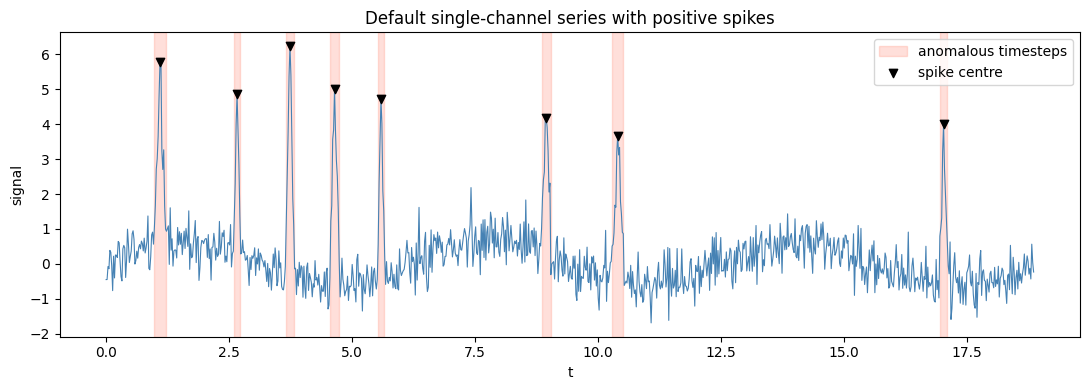

In [2]:
data = make_anomaly_dataset(series_length=1000, random_state=0)

print(f"y shape      : {tuple(data.y.shape)}")  # (m, T)
print(f"labels shape : {tuple(data.labels.shape)}")
print(f"spikes       : {data.peak_indices.tolist()}")

anomalous = data.labels.bool().numpy()
peaks = data.peak_indices

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(data.t, data.y[0], lw=0.8, color="steelblue")
ymin, ymax = ax.get_ylim()
ax.fill_between(
    data.t,
    ymin,
    ymax,
    where=anomalous,
    color="tomato",
    alpha=0.2,
    label="anomalous timesteps",
)
ax.scatter(
    data.t[peaks],
    data.y[0][peaks],
    color="black",
    marker="v",
    zorder=5,
    label="spike centre",
)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("t")
ax.set_ylabel("signal")
ax.set_title("Default single-channel series with positive spikes")
ax.legend()
plt.tight_layout()
plt.show()

## Tuning the spikes with `SpikeParams`

Every spike property is random but configurable through the `SpikeParams` dataclass: `amplitude_range` (sampled per channel), `width_range` (the triangular half-width), `count_range` (number of spike events), and `margin` (keeps spikes off the edges). Each value is drawn uniformly from its inclusive range.

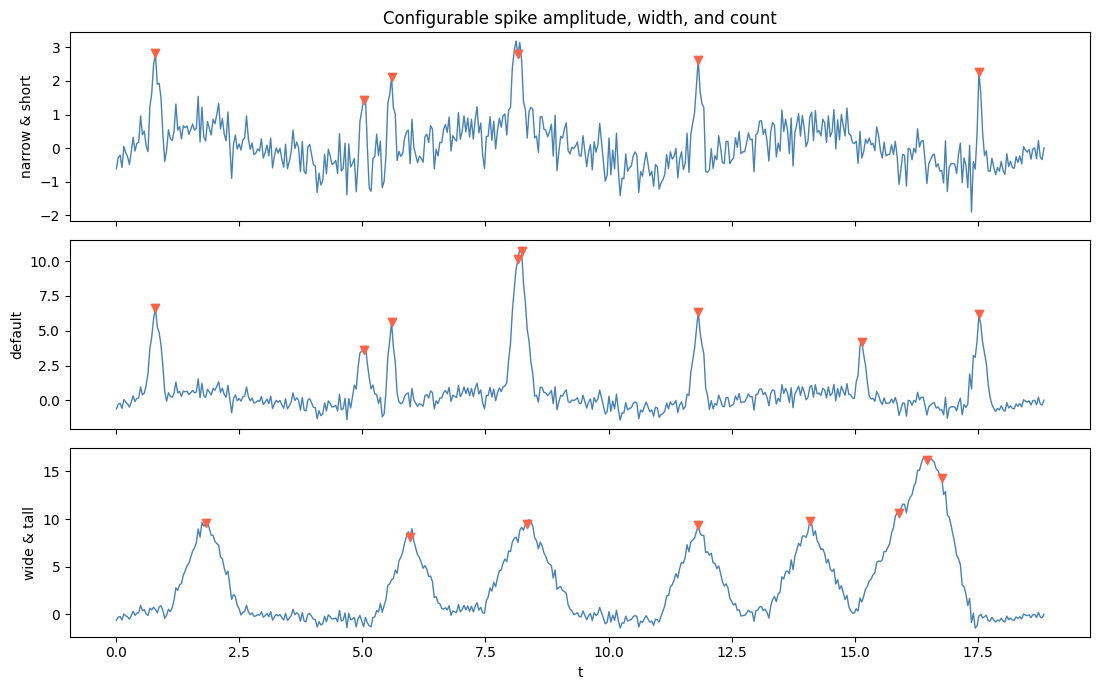

In [3]:
configs = {
    "narrow & short": SpikeParams(
        amplitude_range=(2.0, 3.0), width_range=(2, 4), count_range=(4, 6)
    ),
    "default": SpikeParams(),
    "wide & tall": SpikeParams(
        amplitude_range=(8.0, 10.0), width_range=(15, 25), margin=40
    ),
}

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, (name, spikes) in zip(axes, configs.items(), strict=True):
    d = make_anomaly_dataset(series_length=500, spike_params=spikes, random_state=1)
    ax.plot(d.t, d.y[0], lw=1.0, color="steelblue")
    ax.scatter(
        d.t[d.peak_indices],
        d.y[0][d.peak_indices],
        color="tomato",
        marker="v",
        zorder=5,
    )
    ax.set_ylabel(name)
axes[-1].set_xlabel("t")
axes[0].set_title("Configurable spike amplitude, width, and count")
plt.tight_layout()
plt.show()

## Custom baseline

`channel_params` is a list of signal-parameter dicts — one per channel. Any combination of `"linear"`, `"polynomial"`, and `"sinusoidal"` keys defines the normal-behaviour pattern that the spikes are added on top of.

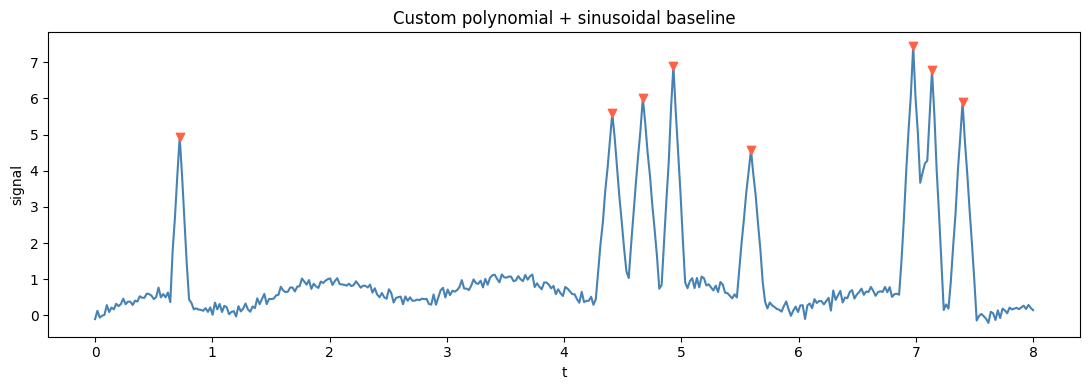

In [4]:
channel_params = [
    {
        "polynomial": {"coefficients": [0.0, 0.5, -0.1, 0.005]},
        "sinusoidal": {"amplitude": 0.3, "frequency": 4.0, "phase": 0.0},
    }
]

data_custom = make_anomaly_dataset(
    series_length=400,
    noise_std=0.1,
    x_range=(0.0, 8.0),
    channel_params=channel_params,
    random_state=2,
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(data_custom.t, data_custom.y[0], color="steelblue")
ax.scatter(
    data_custom.t[data_custom.peak_indices],
    data_custom.y[0][data_custom.peak_indices],
    color="tomato",
    marker="v",
    zorder=5,
)
ax.set_xlabel("t")
ax.set_ylabel("signal")
ax.set_title("Custom polynomial + sinusoidal baseline")
plt.tight_layout()
plt.show()

## Multivariate channels

Pass more than one entry to `channel_params` to get `m > 1` rows in `y`. Each spike *event* shares its centre and width across all channels — one event hits every channel at the same time — while each channel responds with its own random amplitude. The shared `peak_indices` therefore line up across channels.

y shape : (2, 600)


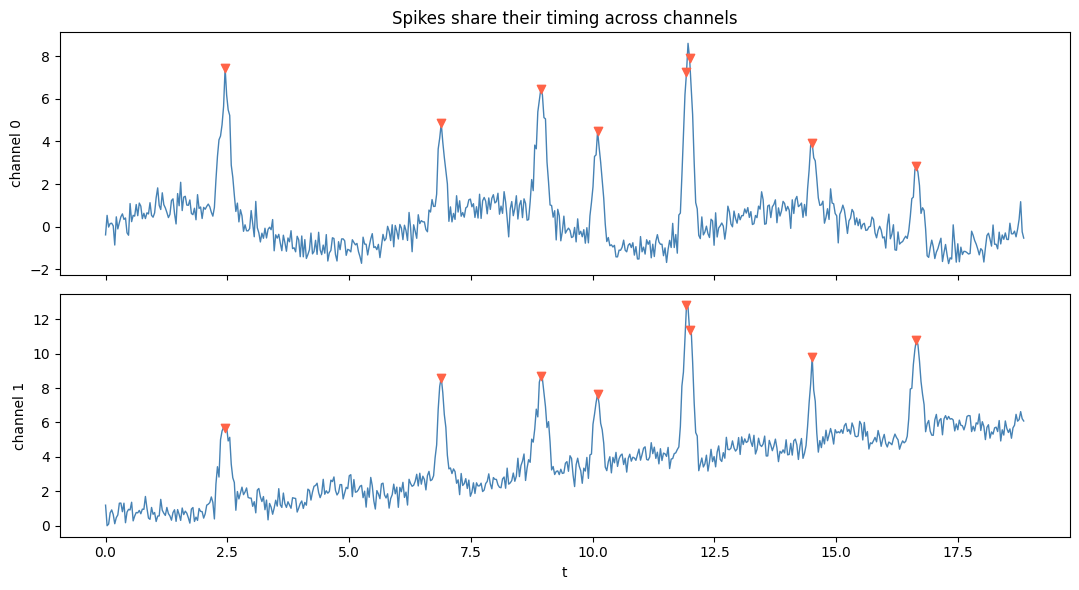

In [5]:
channel_params_mc = [
    {"sinusoidal": {"amplitude": 1.0, "frequency": 1.0, "phase": 0.0}},
    {
        "linear": {"slope": 0.3, "intercept": 0.5},
        "sinusoidal": {"amplitude": 0.4, "frequency": 3.0, "phase": 0.0},
    },
]

data_mc = make_anomaly_dataset(
    series_length=600,
    channel_params=channel_params_mc,
    random_state=4,
)
print(f"y shape : {tuple(data_mc.y.shape)}")  # (2, T)

peaks = data_mc.peak_indices
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(data_mc.t, data_mc.y[ch], lw=1.0, color="steelblue")
    ax.scatter(
        data_mc.t[peaks],
        data_mc.y[ch][peaks],
        color="tomato",
        marker="v",
        zorder=5,
    )
    ax.set_ylabel(f"channel {ch}")
axes[0].set_title("Spikes share their timing across channels")
axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

## Train / validation / test splitting along time

Pass `split=(train, val, test)` to receive an `AnomalySplits` instead of a single dataset. The timeline is cut **contiguously from the beginning**: the first fraction of the `T` timesteps becomes `train`, the next `val`, and the remainder `test`. Each segment keeps the spikes it contains, with `peak_indices` re-based to local positions. The same partition is available as `dataset.split((...))` on an existing dataset.

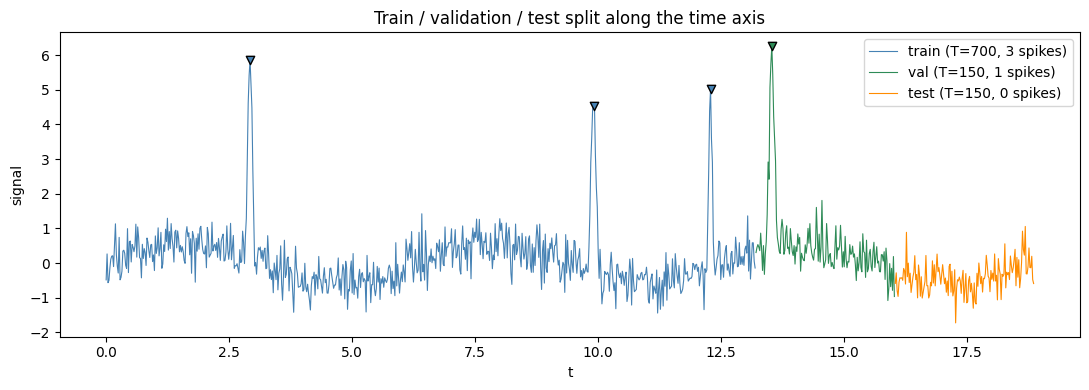

In [6]:
splits = make_anomaly_dataset(
    series_length=1000,
    split=(0.7, 0.15, 0.15),
    random_state=6,
)

segments = [
    ("train", splits.train, "steelblue"),
    ("val", splits.val, "seagreen"),
    ("test", splits.test, "darkorange"),
]

fig, ax = plt.subplots(figsize=(11, 4))
for name, subset, color in segments:
    n_spikes = subset.peak_indices.numel()
    ax.plot(
        subset.t,
        subset.y[0],
        color=color,
        lw=0.8,
        label=f"{name} (T={subset.y.shape[1]}, {n_spikes} spikes)",
    )
    ax.scatter(
        subset.t[subset.peak_indices],
        subset.y[0][subset.peak_indices],
        color=color,
        marker="v",
        edgecolor="black",
        zorder=5,
    )
ax.set_xlabel("t")
ax.set_ylabel("signal")
ax.set_title("Train / validation / test split along the time axis")
ax.legend()
plt.tight_layout()
plt.show()

## Windowing for a PyTorch `DataLoader`

A single long series is usually fed to a model as a batch of fixed-length windows. We slice the `(m, T)` tensor into overlapping windows of shape `(m, W)` and label each window anomalous if it overlaps any spike, then wrap them in a `TensorDataset`.

In [7]:
data_win = make_anomaly_dataset(series_length=1000, random_state=3)

window, stride = 64, 32
n_channels, t_len = data_win.y.shape
starts = range(0, t_len - window + 1, stride)

windows = torch.stack([data_win.y[:, s : s + window] for s in starts])
window_labels = torch.tensor(
    [int(data_win.labels[s : s + window].any()) for s in starts]
)

dataset = TensorDataset(windows, window_labels)
loader = DataLoader(dataset, batch_size=8, shuffle=True)
batch_x, batch_y = next(iter(loader))

print(f"Windows tensor shape : {tuple(windows.shape)}")  # (n_win, m, W)
print(f"Anomalous windows    : {int(window_labels.sum())} / {len(windows)}")
print(f"Batch x shape        : {tuple(batch_x.shape)}")
print(f"Batch y shape        : {tuple(batch_y.shape)}")

Windows tensor shape : (30, 1, 64)
Anomalous windows    : 11 / 30
Batch x shape        : (8, 1, 64)
Batch y shape        : (8,)


## Evaluating a detector with `ClassifierMetrics`

Because the spikes are always positive and much taller than the noisy baseline, a simple per-timestep rule — flag every timestep whose value crosses a threshold — already recovers most of the anomalous samples. `ClassifierMetrics.from_anomaly_indices` compares the detected timesteps against the ground-truth `labels`.

In [8]:
data_ev = make_anomaly_dataset(series_length=1000, random_state=10)

# Detector: a timestep is anomalous if any channel crosses a threshold
# sitting well past the noisy baseline envelope.
timestep_max = data_ev.y.amax(dim=0)
pred_indices = (timestep_max > 2.0).nonzero(as_tuple=True)[0]
true_indices = (data_ev.labels == 1).nonzero(as_tuple=True)[0]

metrics = ClassifierMetrics.from_anomaly_indices(
    n_samples=data_ev.y.shape[1],
    true_indices=true_indices,
    pred_indices=pred_indices,
)

print(f"Accuracy  : {metrics.accuracy:.3f}")
print(f"Precision : {metrics.precision:.3f}")
print(f"Recall    : {metrics.recall:.3f}")
print(f"F1 score  : {metrics.f1_score:.3f}")
print()
print("Confusion matrix (rows = true, cols = predicted):")
print(metrics.confusion_matrix)

Accuracy  : 0.976
Precision : 0.987
Recall    : 0.848
F1 score  : 0.904

Confusion matrix (rows = true, cols = predicted):
tensor([[921,   0],
        [ 24,  55]])
